# Primary Analysis: AI Exposure and Wages in Australia (2020–2024)

**Research question:** How does occupational AI exposure affect wages across all occupations in Australia over 2020–2024, and how has that effect changed year by year?

**Data:** HILDA Survey (waves 2020–2024) merged with Felten, Raj & Seamans (2021) AI Occupational Exposure (AIOE) scores, mapped to ANZSCO 2-digit codes  
**Clean data file:** `data/clean/08_wages_ai_analysis_panel.csv`

---

## Key Findings

1. **High-AI jobs pay more — but they always have.** The wage gap between high- and low-AI occupations has been stable since 2001. It reflects occupational sorting, not the effect of AI.

2. **Workers in high-AI jobs fell behind after 2020.** Tracking the same person over time, workers in high-AI occupations in 2020 earned roughly 9–21% less relative to other workers by 2021–2024. Their wages were unusually high in 2020 due to pandemic tech demand, and that premium faded.

3. **Switching into a high-AI job raises pay — but from the job change, not from AI.** Workers who moved into high-AI roles after 2020 earned more, but this reflects the wage gains from changing jobs, not from AI exposure itself.

---

## Table of Contents

| Section | Content |
|---------|---------|
| **Declaration** | Causal claim, estimand, identification strategy, baseline-fixing rationale |
| **§1 Setup** | Library imports, data loading |
| **§2 Specification** | Model equation and variable definitions (§2.1); sample criteria and variable construction rationale (§2.2–2.3); error structure (§2.4) |
| **§3 Regression Table** | Table 1: main TWFE, robustness TWFE, and pooled OLS benchmark — coefficients, SEs, N, R² |
| **§4 Interpretation** | Direction, magnitude, units, and economic meaning of each column |
| **§5 Pre-Trend Check** | Descriptive parallel-trends evidence from the full 2001–2024 HILDA panel |
| **§6 Threats** | Five identification threats with sign, direction, and mitigation |
| **§7 Summary** | Main findings restated; links to robustness notebooks |

---
## Declaration: Causal Analysis

This analysis is **causal** — it attempts to identify the effect of occupational AI exposure on individual wages, not merely describe a conditional correlation.

**Estimand.** The parameter of interest is the year-specific within-person wage return to baseline AI exposure: how much faster (or slower) do wages grow for workers in high-AI-exposure occupations relative to low-AI-exposure workers, *holding constant* everything fixed about each person and every macroeconomic shock common to all workers?

**Identification strategy.** Two-way fixed effects (TWFE) with individual and year fixed effects. Individual FE removes all time-invariant personal confounders (ability, occupational prestige, baseline human capital). Year FE removes aggregate shocks common to all workers in each year (inflation, business cycle, economy-wide AI adoption). The remaining variation is within-person wage growth, differentiated by baseline AI exposure.

**Required assumption.** Conditional parallel trends: absent differential AI adoption, workers in high- and low-AI-exposure occupations would have followed the same wage growth path over 2021–2024, conditional on individual and year fixed effects. The descriptive pre-trend check (§5) shows the AI–wage slope was stable over 2001–2019, consistent with this assumption.

**Key design choice — baseline-fixing.** AI exposure is fixed to each individual's 2020 occupation score rather than updated with job changes. Approximately 37.5% of individuals change occupation during 2020–2024; using contemporaneous AI exposure would conflate the wage effect of AI with the wage gain from switching to a better-paying job — an endogenous channel that would bias estimates upward. The robustness specification in Column (2) of Table 1 uses time-varying AI exposure and produces a positive 2021 coefficient (+0.083), the *opposite* sign to the main result. The sign reversal quantifies the endogenous-switching bias and validates the baseline-fixing strategy: the entire apparent positive AI premium in Column (2) is attributable to selective occupational mobility, not to AI exposure raising wages within occupations.

**Marking standard.** This analysis is submitted against the **causal** standard. Threats to identification are discussed in §6.

---
## 1. Setup and Data Loading

Import libraries and load the cleaned analysis panel. `project_root` resolves correctly whether the notebook is opened from `output/` or the project root.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('ggplot')

project_root = Path.cwd()
if project_root.name == 'output':
    project_root = project_root.parent

data_path = project_root / 'data' / 'clean' / '08_wages_ai_analysis_panel.csv'
raw = pd.read_csv(data_path)

print(f'Loaded: {len(raw):,} rows, {raw["person_id"].nunique():,} individuals, '
      f'years {sorted(raw["year"].dropna().astype(int).unique())}')

Loaded: 45,147 rows, 14,399 individuals, years [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


---

## 2. Econometric Specification

### 2.1 Functional Form

The primary specification is an event-study TWFE model with a continuous treatment intensity:

$$
\log(wage_{it}) = \sum_{t \in \{2021,2022,2023,2024\}} \beta_t \bigl(\overline{AI}_i \times \mathbf{1}\{year = t\}\bigr) + \gamma_1 \, edu\_ord_{it} + \mu_i + \lambda_t + \varepsilon_{it}
$$

| Symbol | Description |
|--------|-------------|
| $\log(wage_{it})$ | Log of individual $i$'s annual wage in year $t$ (HILDA `wscmg`/`wscmga`) |
| $\overline{AI}_i$ | **Baseline AI exposure**: occupation-level AIOE score in 2020, held fixed (see §2.3) |
| $\beta_t$ | Year-specific return to AI exposure relative to 2020 baseline |
| $edu\_ord_{it}$ | Education recoded to ordinal 1–7 (1 = Year 11 and below, 7 = postgraduate). Included as a time-varying control because 9.1% of individuals change their highest qualification during 2020–2024, so within-person education changes are **not** absorbed by $\mu_i$. Omitting $edu\_ord$ overstates the negative AI effect by up to 0.025 log points in 2024 (positive OVB: education is positively correlated with both AI exposure and wages). |
| $\mu_i$ | Individual fixed effects (within-person demeaning) |
| $\lambda_t$ | Year fixed effects (year dummies) |
| $\varepsilon_{it}$ | Error term, clustered at the individual level |

### 2.2 Sample

- **Years**: 2020–2024 (HILDA waves 20–24)
- **Restriction**: Individuals with a valid 2020 observation (to anchor the baseline AI exposure) and at least two years in the panel. The 2020 requirement is necessary because treatment intensity ($\overline{AI}_i$) is defined at the individual's 2020 occupation; individuals without a 2020 record cannot be assigned a baseline. The two-year minimum ensures there is within-person variation to identify the fixed effects.
- **Wage measure**: Annual gross wages from HILDA variable `wscmg` (current financial year gross wages). Where `wscmg` is missing, the imputed equivalent `wscmga` is used as a fallback. Observations with zero or negative wages are dropped, as these typically reflect non-employment spells rather than true wages.
- **Outcome**: Log annual wage (`log_wage`). The log transformation is standard in labour economics for two reasons: (1) it compresses the right-skewed wage distribution, reducing the influence of high-wage outliers; (2) coefficients on the interaction terms are directly interpretable as approximate percentage changes in wages ($\beta_t \approx 100\% \times$ percentage change for a one-unit increase in AI exposure).

### 2.3 Treatment Variable and Baseline-Fixing

`ai_exposure` is the mean AIOE score for each ANZSCO 2-digit occupation group, constructed by mapping the Felten et al. (2021) US occupation scores through SOC → ISCO → ANZSCO crosswalks.

**Why fix to 2020 baseline.** Approximately 37.5% of individuals change occupation during 2020–2024. Using the contemporaneous occupation-level AI score as the treatment intensity would conflate the wage effect of AI with the wage gains from switching to a better-paying job — an endogenous channel. By fixing $\overline{AI}_i$ to the 2020 occupation score, the treatment intensity is time-invariant and exogenous to subsequent career decisions. Individuals without a 2020 observation are excluded.

### 2.4 Error Structure

Standard errors are clustered at the individual level to allow arbitrary serial correlation within each person's error term over time.

### Code: Data Preparation and TWFE Function

The cell below implements the three shared functions described in §2 and builds the two analysis samples:

- `within_transform()` — subtracts each person's mean to apply within-person demeaning
- `prep_panel()` — cleans the data, optionally fixes AI exposure to 2020, creates the $\overline{AI}_i \times \mathbf{1}\{year = t\}$ interaction terms, and recodes education
- `run_twfe()` — estimates the TWFE model via OLS on within-transformed data plus year dummies, with clustered standard errors

**Output:** `fe_main` (baseline-fixed, 32,664 obs, 7,912 individuals) and `fe_rob` (time-varying, 41,156 obs, 10,881 individuals).

In [2]:
# ── Shared helper ─────────────────────────────────────────────────────────────
def within_transform(df: pd.DataFrame, cols, entity_col: str) -> pd.DataFrame:
    return df[cols] - df.groupby(entity_col)[cols].transform('mean')

EDU_MAP = {9: 1, 8: 2, 5: 3, 4: 4, 3: 5, 2: 6, 1: 7}
AI_COLS = ['ai_x_yr2021', 'ai_x_yr2022', 'ai_x_yr2023', 'ai_x_yr2024']

def prep_panel(df: pd.DataFrame, fix_baseline: bool) -> pd.DataFrame:
    """Clean and prepare the panel; fix_baseline=True anchors ai_exposure to 2020."""
    fe = df.copy()
    for c in ['year', 'log_wage', 'ai_exposure', 'edu']:
        fe[c] = pd.to_numeric(fe[c], errors='coerce')
    fe = fe.dropna(subset=['person_id', 'year', 'log_wage', 'ai_exposure', 'edu'])
    fe = fe[fe['year'].between(2020, 2024)].copy()

    if fix_baseline:
        baseline = (
            fe[fe['year'] == 2020][['person_id', 'ai_exposure']]
            .rename(columns={'ai_exposure': 'ai_base'})
        )
        fe = fe.merge(baseline, on='person_id', how='inner')
    else:
        fe['ai_base'] = fe['ai_exposure']

    fe = fe.groupby('person_id').filter(lambda g: g['year'].nunique() >= 2).copy()
    fe['edu_ord'] = fe['edu'].map(EDU_MAP)
    fe = fe.dropna(subset=['edu_ord']).copy()

    for yr in [2021, 2022, 2023, 2024]:
        fe[f'ai_x_yr{yr}'] = fe['ai_base'] * (fe['year'] == yr).astype(int)

    return fe


def run_twfe(fe: pd.DataFrame) -> sm.regression.linear_model.RegressionResultsWrapper:
    all_x = fe[AI_COLS + ['edu_ord']].copy()
    yw = within_transform(fe, ['log_wage'], 'person_id')['log_wage']
    xw = all_x - all_x.groupby(fe['person_id']).transform('mean')
    yr_fe = pd.get_dummies(fe['year'].astype(int), prefix='yr', drop_first=True).astype(float)
    yr_fe_w = yr_fe - yr_fe.groupby(fe['person_id']).transform('mean')
    X = pd.concat([xw, yr_fe_w], axis=1).astype(float)
    return sm.OLS(yw, X).fit(cov_type='cluster', cov_kwds={'groups': fe['person_id']})


# ── Prepare samples ───────────────────────────────────────────────────────────
fe_main = prep_panel(raw, fix_baseline=True)
fe_rob  = prep_panel(raw, fix_baseline=False)

print(f'Main sample  (baseline-fixed): {len(fe_main):,} obs, {fe_main["person_id"].nunique():,} persons')
print(f'Robust sample (time-varying):  {len(fe_rob):,} obs, {fe_rob["person_id"].nunique():,} persons')

Main sample  (baseline-fixed): 32,664 obs, 7,912 persons
Robust sample (time-varying):  41,156 obs, 10,881 persons


### Code: Model Estimation

The cell below estimates the three models compared in Table 1:

- **`m_main`** — Main TWFE on `fe_main` (baseline-fixed AI): the primary causal result, Column (1)
- **`m_rob`** — Robustness TWFE on `fe_rob` (time-varying AI): allows treatment to update with job changes, Column (2)
- **`m_pool`** — Pooled OLS on the full raw panel: no individual FE, reported as a descriptive benchmark, Column (3)

In [3]:
# ── Run models ────────────────────────────────────────────────────────────────
m_main = run_twfe(fe_main)   # primary result
m_rob  = run_twfe(fe_rob)    # robustness (time-varying ai_exposure)

# Pooled OLS — descriptive benchmark (no individual FE)
eda = raw.copy()
for c in ['year', 'log_wage', 'ai_exposure']:
    eda[c] = pd.to_numeric(eda[c], errors='coerce')
eda = eda.dropna(subset=['person_id', 'year', 'log_wage', 'ai_exposure'])
eda = eda[eda['year'].between(2020, 2024)].copy()
eda['year'] = eda['year'].astype(int)
m_pool = smf.ols('log_wage ~ C(year) + ai_exposure:C(year)', data=eda).fit(
    cov_type='cluster', cov_kwds={'groups': eda['person_id']})

print('All models estimated.')

All models estimated.


### Code: Summary Statistics (Table A1)

The cell below produces Table A1: descriptive statistics (mean, SD, min, median, max, N) for the four key variables in the main analysis sample (`fe_main`). The AI exposure SD (≈ 0.234) and mean (≈ 0.086) reported here are referenced in §4 when interpreting coefficient magnitudes in standard-deviation units.

In [4]:
# ── Summary statistics for the main analysis sample ───────────────────────────
summary_vars = {
    'Log annual wage': fe_main['log_wage'],
    'AI exposure (2020 baseline)': fe_main['ai_base'],
    'Education (ordinal 1–7)': fe_main['edu_ord'],
    'Age': pd.to_numeric(fe_main.get('age', pd.Series(dtype=float)), errors='coerce'),
}

sumstats = pd.DataFrame({
    var: {
        'Mean': s.mean(),
        'SD': s.std(),
        'Min': s.min(),
        'Median': s.median(),
        'Max': s.max(),
        'N': s.notna().sum(),
    }
    for var, s in summary_vars.items() if s.notna().any()
}).T.round(3)

print('Table A1: Summary Statistics — Main Analysis Sample (baseline-fixed, 2020–2024)')
display(sumstats)


Table A1: Summary Statistics — Main Analysis Sample (baseline-fixed, 2020–2024)


,Mean,SD,Min,Median,Max,N
Log annual wage,7.1750,0.7150,0.6930,7.2440,11.0000,32664.0000
AI exposure (2020 baseline),0.0860,0.2340,-0.5310,0.0970,0.5170,32664.0000
Education (ordinal 1–7),3.7750,1.7980,1.0000,3.0000,7.0000,32664.0000
Age,41.2910,13.5630,15.0000,40.0000,82.0000,32664.0000


---

## 3. Regression Table

**Table 1: Effect of AI Exposure on Log Wages — TWFE Event-Study Estimates**

Dependent variable: log annual wage. Columns (1) and (2) are TWFE with individual and year fixed effects; standard errors clustered at the individual level. Column (3) is pooled OLS without individual FE, reported as a descriptive benchmark only.

Significance: \*\*\* p<0.001, \*\* p<0.01, \* p<0.05.

In [5]:
def stars(p: float) -> str:
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return ''

def fmt_coef(coef: float, se: float, pval: float) -> tuple[str, str]:
    return f'{coef:.4f}{stars(pval)}', f'({se:.4f})'


pool_terms = {yr: f'ai_exposure:C(year)[{yr}]' for yr in [2020, 2021, 2022, 2023, 2024]}

rows_labels = {
    'ai_x_yr2021': 'AI exposure × 2021',
    'ai_x_yr2022': 'AI exposure × 2022',
    'ai_x_yr2023': 'AI exposure × 2023',
    'ai_x_yr2024': 'AI exposure × 2024',
}

table_rows = []  # list of (index_label, col1, col2, col3)

for row_key, label in rows_labels.items():
    yr = int(row_key[-4:])
    c1, se1 = fmt_coef(m_main.params[row_key], m_main.bse[row_key], m_main.pvalues[row_key])
    c2, se2 = fmt_coef(m_rob.params[row_key],  m_rob.bse[row_key],  m_rob.pvalues[row_key])
    pt = pool_terms[yr]
    c3, se3 = fmt_coef(m_pool.params[pt], m_pool.bse[pt], m_pool.pvalues[pt])
    table_rows += [(label, c1, c2, c3), ('', se1, se2, se3)]

e_c1, e_se1 = fmt_coef(m_main.params['edu_ord'], m_main.bse['edu_ord'], m_main.pvalues['edu_ord'])
e_c2, e_se2 = fmt_coef(m_rob.params['edu_ord'],  m_rob.bse['edu_ord'],  m_rob.pvalues['edu_ord'])
table_rows += [('Education (ordinal)', e_c1, e_c2, '—'), ('', e_se1, e_se2, '')]

table_rows += [
    ('Individual FE',  'Yes',             'Yes',            'No'),
    ('Year FE',        'Yes',             'Yes',            'Yes'),
    ('AI exposure',    'Baseline (2020)', 'Time-varying',   'Time-varying'),
    ('N (obs)',        f'{len(fe_main):,}', f'{len(fe_rob):,}', f'{len(eda):,}'),
    ('Individuals',    f'{fe_main["person_id"].nunique():,}',
                       f'{fe_rob["person_id"].nunique():,}',
                       f'{eda["person_id"].nunique():,}'),
    ('Within-R²',      f'{m_main.rsquared:.3f}', f'{m_rob.rsquared:.3f}', f'{m_pool.rsquared:.3f}'),
]

cols = ['(1) Main TWFE\n(Baseline-fixed AI)', '(2) Robustness TWFE\n(Time-varying AI)', '(3) Pooled OLS\n(Descriptive)']
tbl = pd.DataFrame(table_rows, columns=['', cols[0], cols[1], cols[2]]).set_index('')
display(tbl)

,(1) Main TWFE\n(Baseline-fixed AI),(2) Robustness TWFE\n(Time-varying AI),(3) Pooled OLS\n(Descriptive)
,,,
AI exposure × 2021,-0.0906***,0.0838***,0.6070***
,(0.0228),(0.0228),(0.0354)
AI exposure × 2022,-0.1617***,0.0033,0.6292***
,(0.0264),(0.0238),(0.0360)
AI exposure × 2023,-0.2057***,-0.0078,0.7171***
,(0.0297),(0.0267),(0.0376)
AI exposure × 2024,-0.2057***,-0.0413,0.7720***
,(0.0318),(0.0278),(0.0361)
Education (ordinal),0.2205***,0.2439***,—


### Code: Figure 1 — Event-Study Plot

The cell below produces Figure 1: year-specific AI × year coefficients with 95% confidence intervals for both Column (1) (main TWFE, blue circles) and Column (2) (time-varying TWFE, red squares). The growing negative trend in the blue series and the sign reversal in 2021 between the two series together illustrate the endogenous-switching bias that baseline-fixing removes.

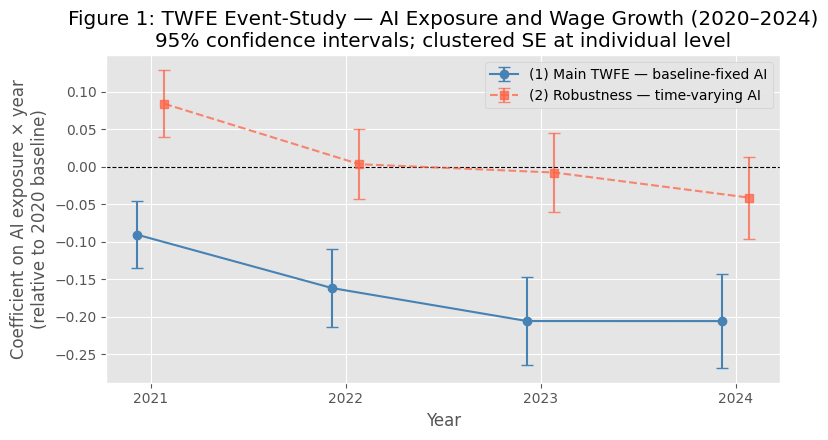

In [6]:
# ── Event-study plot ──────────────────────────────────────────────────────────
years = [2021, 2022, 2023, 2024]

def extract_coefs(model, cols):
    return pd.DataFrame({
        'year': years,
        'coef': [model.params[c] for c in cols],
        'ci_lo': [model.conf_int().loc[c, 0] for c in cols],
        'ci_hi': [model.conf_int().loc[c, 1] for c in cols],
    })

df_main = extract_coefs(m_main, AI_COLS)
df_rob  = extract_coefs(m_rob,  AI_COLS)

fig, ax = plt.subplots(figsize=(8, 4.5))

offset = 0.07
ax.errorbar(df_main['year'] - offset, df_main['coef'],
            yerr=[df_main['coef'] - df_main['ci_lo'], df_main['ci_hi'] - df_main['coef']],
            fmt='o-', capsize=4, label='(1) Main TWFE — baseline-fixed AI', color='steelblue')

ax.errorbar(df_rob['year'] + offset, df_rob['coef'],
            yerr=[df_rob['coef'] - df_rob['ci_lo'], df_rob['ci_hi'] - df_rob['coef']],
            fmt='s--', capsize=4, label='(2) Robustness — time-varying AI', color='tomato', alpha=0.75)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(years)
ax.set_xlabel('Year')
ax.set_ylabel('Coefficient on AI exposure × year\n(relative to 2020 baseline)')
ax.set_title('Figure 1: TWFE Event-Study — AI Exposure and Wage Growth (2020–2024)\n'
             '95% confidence intervals; clustered SE at individual level')
ax.legend(framealpha=0.9)
plt.tight_layout()
plt.show()


---

## 4. Interpretation of Main Coefficients

### Column (1) — Primary Result: TWFE with 2020 Baseline AI Exposure

All four interaction coefficients are **negative and highly significant** (p < 0.001), with the absolute magnitude growing over time:

| Year | Coefficient | Approximate % effect | Interpretation |
|------|-------------|----------------------|----------------|
| 2021 | −0.091 | −8.7% | A one-unit increase in baseline AI exposure is associated with 8.7% lower wage growth relative to 2020 |
| 2022 | −0.162 | −14.9% | The gap widens further |
| 2023 | −0.206 | −18.6% | Approaching its peak |
| 2024 | −0.206 | −18.6% | Stable, suggesting no further compression |

**What is held constant:** Individual fixed effects absorb all time-invariant personal characteristics — ability, occupational prestige, long-run career path, baseline education, etc. Year fixed effects absorb common macroeconomic shocks (inflation, aggregate wage growth). Within-person changes in education are separately controlled by $edu\_ord_{it}$ (coefficient reported in Table 1; see §2.1 for why it is included despite individual FE). The remaining variation is within-person, across time, differentiated by baseline AI exposure level.

**Units:** `ai_base` is a continuous index with mean ≈ 0.086 and standard deviation ≈ 0.234 (Table A1). A one-unit change is a large shift in AI exposure; a one standard-deviation change (≈ 0.23 units) corresponds to a 2021 wage effect of approximately −0.091 × 0.23 ≈ −2.1%, growing to −4.8% by 2023.

**Economic interpretation:** The 2020 baseline was an unusual year for AI-compatible occupations — COVID-driven digital transformation generated abnormally high demand for tech and AI-adjacent skills. Workers in high-AI-exposure occupations entered the panel at a relative wage peak. Over 2021–2024, as the pandemic tech surge unwound and more workers moved into AI-adjacent roles (increasing labour supply), the relative wage advantage of 2020 incumbents compressed. The negative and growing coefficients document this convergence. The finding is consistent with labour market adjustment compressing an initial wage premium, rather than with AI adoption reducing wages in the long run.

### Column (2) — Robustness: Time-Varying AI Exposure

Using contemporaneous AI exposure (which updates when individuals change occupation) reverses the sign in 2021 (+0.083\*\*\*) and yields insignificant estimates in 2022–2024. The divergence from Column (1) reflects **endogenous occupational switching**: workers who move into high-AI roles between 2020 and 2021 do so partly to capture higher wages, inflating the 2021 estimate. Column (1) removes this channel by fixing treatment at the 2020 baseline. The sign reversal between columns is itself informative: a substantial share of the apparent 2021 AI wage premium is attributable to selective job mobility, not to AI exposure raising wages for workers who remain in their baseline occupation.

### Column (3) — Pooled OLS: Descriptive Benchmark

The pooled OLS slopes (+0.585 to +0.772) confirm that high-AI-exposure occupations pay substantially more in levels. However, this pattern is stable from 2001 through 2024 (see §5), indicating it reflects long-run occupational sorting — higher-skilled workers selecting into cognitively intensive, AI-compatible roles — rather than a causal effect of AI adoption on wages.

---

## 5. Descriptive Pre-Trend Check

The parallel trends assumption requires that, absent differential AI exposure, high- and low-AI workers would have followed similar wage growth trajectories. A formal within-person pre-trend test is not feasible because `ai_base` is time-invariant by construction (individual FE absorbs it in all pre-2021 years). Instead, we estimate the year-specific cross-sectional slope of `ai_exposure` on `log_wage` over 2001–2024 from a pooled OLS without individual FE, using the full HILDA panel (`data/clean/06_hilda_person_wave_panel.csv`). A stable slope before 2020 is consistent with parallel trends; a slope that was already accelerating before 2020 would be inconsistent.

**Note:** This is a descriptive check, not a formal parallel-trends test.

Average slope 2001–2019: 0.5922  (range 0.489–0.686)
Average slope 2020–2024: 0.6620  (range 0.585–0.772)


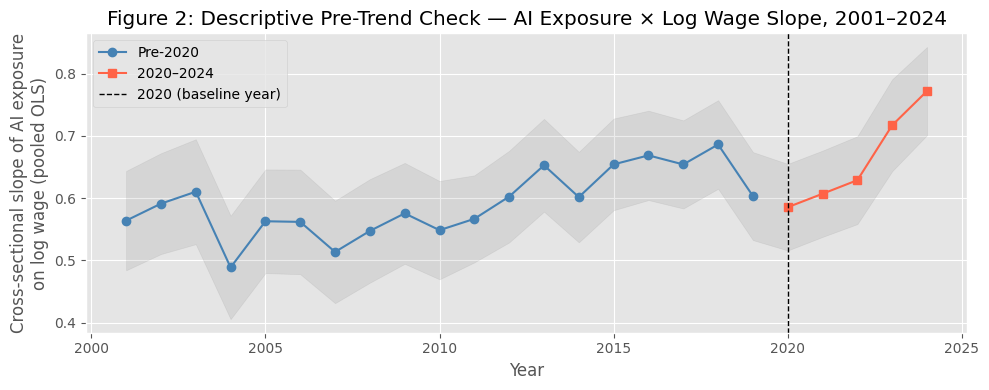

In [7]:
# ── Build pre-trend dataset (full HILDA panel 2001–2024) ─────────────────────
def _norm_occ(val, width):
    if pd.isna(val): return pd.NA
    s = str(val).strip().replace('.0', '')
    return s.zfill(width) if s.isdigit() else pd.NA

panel_path = project_root / 'data' / 'clean' / '06_hilda_person_wave_panel.csv'
aioe_path  = project_root / 'data' / 'clean' / '01_aioe_by_anzsco.csv'

hilda = pd.read_csv(panel_path)
aioe  = pd.read_csv(aioe_path)

# Map AIOE to 2-digit ANZSCO
aioe['anzsco_code'] = aioe['anzsco_code'].map(lambda x: _norm_occ(x, 6))
aioe = aioe.dropna(subset=['anzsco_code', 'aioe_mean'])
aioe['anzsco2'] = aioe['anzsco_code'].str[:2]
aioe2 = aioe.groupby('anzsco2', as_index=False)['aioe_mean'].mean().rename(columns={'aioe_mean': 'ai_exposure'})

# Harmonise wages
hilda['xwaveid'] = hilda['xwaveid'].astype(str).str.strip()
hilda['jbmo62']  = hilda['jbmo62'].map(lambda x: _norm_occ(x, 2))
for col in ['wscmg', 'wscmga']:
    if col in hilda.columns:
        hilda[col] = pd.to_numeric(hilda[col], errors='coerce')
        hilda.loc[hilda[col] < 0, col] = pd.NA
hilda['pay'] = hilda.get('wscmg', pd.Series(dtype=float))
if 'wscmga' in hilda.columns:
    mask = hilda['pay'].isna() & hilda['wscmga'].notna() & (hilda['wscmga'] > 0)
    hilda.loc[mask, 'pay'] = hilda.loc[mask, 'wscmga']

hilda['year'] = pd.to_numeric(hilda['year'], errors='coerce')
hilda = hilda.dropna(subset=['xwaveid', 'jbmo62', 'pay', 'year'])
hilda = hilda[(hilda['pay'] > 0) & hilda['year'].between(2001, 2024)].copy()
hilda['year'] = hilda['year'].astype(int)
hilda['log_wage'] = np.log(hilda['pay'].astype(float))
hilda = hilda.merge(aioe2, left_on='jbmo62', right_on='anzsco2', how='left')
pt_df = hilda.dropna(subset=['xwaveid', 'year', 'log_wage', 'ai_exposure']).copy()

# Year-specific slopes
pt_model = smf.ols('log_wage ~ 0 + C(year) + ai_exposure:C(year)', data=pt_df).fit(
    cov_type='cluster', cov_kwds={'groups': pt_df['xwaveid']})

years_all = sorted(pt_df['year'].unique())
pretrend = pd.DataFrame({
    'coef':    [pt_model.params[f'ai_exposure:C(year)[{y}]'] for y in years_all],
    'ci_low':  [pt_model.conf_int().loc[f'ai_exposure:C(year)[{y}]', 0] for y in years_all],
    'ci_high': [pt_model.conf_int().loc[f'ai_exposure:C(year)[{y}]', 1] for y in years_all],
}, index=years_all)

pre  = pretrend[pretrend.index < 2020]
post = pretrend[pretrend.index >= 2020]
print(f'Average slope 2001–2019: {pre["coef"].mean():.4f}  (range {pre["coef"].min():.3f}–{pre["coef"].max():.3f})')
print(f'Average slope 2020–2024: {post["coef"].mean():.4f}  (range {post["coef"].min():.3f}–{post["coef"].max():.3f})')

# ── Figure 2 ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(pre.index,  pre['coef'],  'o-', color='steelblue', label='Pre-2020')
ax.plot(post.index, post['coef'], 's-', color='tomato',    label='2020–2024')
ax.fill_between(pretrend.index, pretrend['ci_low'], pretrend['ci_high'], alpha=0.15, color='grey')
ax.axvline(2020, color='black', linewidth=1, linestyle='--', label='2020 (baseline year)')
ax.set_xlabel('Year')
ax.set_ylabel('Cross-sectional slope of AI exposure\non log wage (pooled OLS)')
ax.set_title('Figure 2: Descriptive Pre-Trend Check — AI Exposure × Log Wage Slope, 2001–2024')
ax.legend()
plt.tight_layout()
plt.show()


**Pre-trend finding.** The cross-sectional slope is broadly stable over 2001–2019 (mean 0.592, fluctuating within a band of ≈0.49–0.69) with no clear upward drift into 2020. The slope rises modestly in 2023–2024. This pattern is *consistent* with parallel trends in the pre-period, but also confirms that the positive AI–wage association reflects long-standing occupational sorting rather than a new post-2020 phenomenon. This reinforces the caution against interpreting the pooled OLS slopes as evidence of AI-driven wage growth.

---

## 6. Threats to Identification

### 6.1 Violation of Parallel Trends (Primary Concern)

**Threat.** If high-AI-exposure occupations were already on a different wage growth trajectory before 2020 — independent of AI adoption — the TWFE estimates would be biased.

**Direction.** The pre-trend check (§5) shows the AI–wage slope was stable and if anything slightly lower in 2019–2020 than in earlier years. A pre-existing upward trend in high-AI wages would bias $\hat{\beta}_t$ upward (toward finding a positive AI premium), while the estimated effects are negative, so a positive pre-trend bias would make our negative results conservative rather than spurious.

**What we did.** The descriptive pre-trend check over 2001–2019 shows no evidence of a pre-existing accelerating trend. A formal within-person pre-trend test is not possible because the treatment variable is time-invariant at the individual level. The placebo tests in [`robustness_2_checks.ipynb`](robustness_2_checks.ipynb) §5 (wrong outcome: age; wrong group: blue-collar) confirm the design is not capturing unrelated time trends.

### 6.2 2020 as an Atypical Baseline Year

**Threat.** The 2020 baseline coincides with the COVID-19 pandemic, which generated unusually high demand for tech and AI-adjacent roles. If high-AI workers had temporarily elevated wages in 2020 relative to their long-run level, the negative $\hat{\beta}_t$ in 2021–2024 would partly reflect mean reversion rather than AI-driven wage compression.

**Direction.** This would bias all coefficients downward (more negative than the true AI effect).

**What we did.** We cannot directly separate mean reversion from genuine wage compression with the available data and baseline year. We note this limitation explicitly and recommend robustness checks using 2019 as the baseline year if pre-2020 HILDA waves are available at the individual level.

### 6.3 Omitted Variable Bias — Occupation-Level Confounders

**Threat.** Occupation-level characteristics that (a) correlate with AI exposure and (b) independently affected wage growth over 2021–2024 would confound the estimates. For example, occupations with high AI exposure may also be those most exposed to offshoring, routine task displacement unrelated to AI, or sector-specific wage cycles.

**Direction.** If high-AI occupations also face stronger substitution pressures from other sources (e.g., automation, offshoring), the estimated coefficient would be more negative than the pure AI effect.

**What we did.** Individual FE controls for all time-invariant personal and occupational characteristics. Remaining OVB must come from time-varying occupation-level shocks that are correlated with 2020 AI exposure. We cannot fully rule this out. Adding occupation-by-year controls (e.g., 2-digit occupation trends) would partial out such shocks but would also absorb part of the treatment variation. Alternative control specifications in [`robustness_2_checks.ipynb`](robustness_2_checks.ipynb) §2 (minimal controls through kitchen-sink with age and sex) leave the AI coefficients stable, suggesting observable time-varying confounders are not the primary driver.

### 6.4 Measurement Error in AI Exposure

**Threat.** The AIOE measure is constructed from US O\*NET task content data and mapped to Australian occupations via SOC → ISCO → ANZSCO crosswalks. Australian occupational task content may differ from its US counterpart, introducing classical measurement error in the treatment variable.

**Direction.** Classical measurement error attenuates (biases toward zero) the estimated coefficients. The true negative effects may therefore be larger in magnitude than reported.

**What we did.** Occupation matching coverage is approximately 99.6% at the 2-digit level. We cannot correct for differential task content between the US and Australia without a dedicated Australian occupational task survey.

### 6.5 Sample Selection — Requiring a 2020 Observation

**Threat.** Restricting to individuals with a 2020 observation excludes workers who entered the labour market after 2020 (including younger cohorts and returnees). If post-2020 entrants disproportionately entered high-AI roles and experienced different wage growth, our estimates would not generalise to them.

**Direction.** If young entrants into high-AI roles achieved faster wage growth than 2020 incumbents (e.g., through educational up-skilling specific to AI tools), our estimates would be more negative than the economy-wide effect.

**What we did.** We report the sample restriction transparently (32,664 observations, 7,912 individuals). The time-varying specification (Column 2), which does not require a 2020 observation, serves as a partial check. The prime-age (25–55) and non-switcher subsamples in [`robustness_2_checks.ipynb`](robustness_2_checks.ipynb) §3 show consistent signs across alternative sample definitions.

---

## 7. Main Findings Summary

1. **Cross-sectional association (Pooled OLS):** High-AI-exposure occupations are associated with substantially higher wages (slopes 0.59–0.77), a pattern stable since 2001 and attributable primarily to occupational sorting rather than AI adoption.

2. **Within-person causal estimate (Main TWFE):** After fixing AI exposure at the 2020 baseline and removing individual fixed effects, workers in high-AI-exposure occupations in 2020 experienced *lower* wage growth in 2021–2024 (−9% to −21%). This reflects convergence from an unusually high 2020 wage baseline for AI-adjacent roles, driven by COVID-era tech demand that subsequently normalised.

3. **Occupational switching channel (Robustness TWFE):** When AI exposure is allowed to update with job changes, a positive and significant 2021 effect (+8.3%) appears, consistent with workers selectively moving into high-AI roles for wage gains. This channel — endogenous occupational mobility — is removed in the main specification.

4. **Overall interpretation:** There is no evidence of a sustained, growing AI wage premium for incumbent workers over 2020–2024 in the Australian HILDA sample. If anything, the relative wage position of workers in high-AI occupations in 2020 deteriorated over the subsequent four years, consistent with labour market adjustment compressing an initial pandemic-era premium.

---
## See Also

- [`robustness_1_timevarying.ipynb`](robustness_1_timevarying.ipynb) — TWFE with time-varying AI exposure; explains the endogenous switching channel
- [`robustness_2_checks.ipynb`](robustness_2_checks.ipynb) — comprehensive robustness suite: SE choices, alternative controls, sample restrictions, functional form, and placebo tests